# Supervised Classification: Cleveland Heart Disease

Binary classification of heart disease presence using an SVM and a decision tree on the Cleveland Heart Disease dataset ([UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease)): exploratory analysis, target binarization, model comparison with confusion matrices and classification reports, and hyperparameter tuning with grid search.

*Coursework - BSc in Applied Data Science, Universitat Oberta de Catalunya (UOC), Machine Learning course. Narrative translated to English from the original Spanish; printed outputs and figure labels are shown as originally executed (in Spanish).*

## 1. Loading the data

The dataset is fetched from the UCI Machine Learning Repository via the `ucimlrepo` package.

In [1]:
# Provided by course materials

!pip3 install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
features = heart_disease.data.features
targets = heart_disease.data.targets

## 2. Exploratory analysis and preprocessing

In [2]:
# Combine features and targets for a simpler analysis
import pandas as pd
targets_df = targets.copy()
targets_df.columns = ['target']

heart_disease_df = pd.concat([features, targets_df], axis=1)

#We count the number of attributes
num_attributes = features.shape[1]
print(f'Número de atributos: {num_attributes}')

#We identify the unique values of the target variable and their meanings
unique_targets = heart_disease_df['target'].unique()
print(f'Valores únicos en la variable objetivo: {unique_targets}')
# Note: You should consult the dataset description to interpret these values

#We check for and remove samples with null values
null_values = heart_disease_df.isnull().sum()
print(f'Valores nulos por columna antes de la limpieza:\n{null_values}')

#We remove samples with null values
heart_disease_df_cleaned = heart_disease_df.dropna()

# We check the null values again to confirm the cleaning
null_values_after_cleaning = heart_disease_df_cleaned.isnull().sum()
print(f'Valores nulos por columna después de la limpieza:\n{null_values_after_cleaning}')

Número de atributos: 13
Valores únicos en la variable objetivo: [0 2 1 3 4]
Valores nulos por columna antes de la limpieza:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Valores nulos por columna después de la limpieza:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


How many attributes does the dataset include?

The dataset includes 13 attributes. These attributes are features or independent variables used to predict the outcome of the target variable.


How many values can the variable to be predicted (labels, target) take, and what event do they correspond to according to the dataset description?

The target variable (target) can take 5 unique values: 0, 1, 2, 3, 4. According to the description of the Cleveland heart disease dataset, these values represent:
0: No indication of heart disease. This means that the patient does not present heart disease conditions according to the study's criteria.
1 to 4: Indications of heart disease of varying degree, with 1 being the least severe and 4 the most severe. These degrees may refer to the severity of the stenosis (narrowing of the arteries) or other cardiac factors evaluated in the study.


Does it include null values?

Yes, the dataset includes null values before cleaning:
4 null values in the ca column, which represents the number of major blood vessels (0-3) identified by fluoroscopy.
2 null values in the thal column, which is an attribute referring to cardiac thallium stress.

### Class distribution and target binarization

target
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


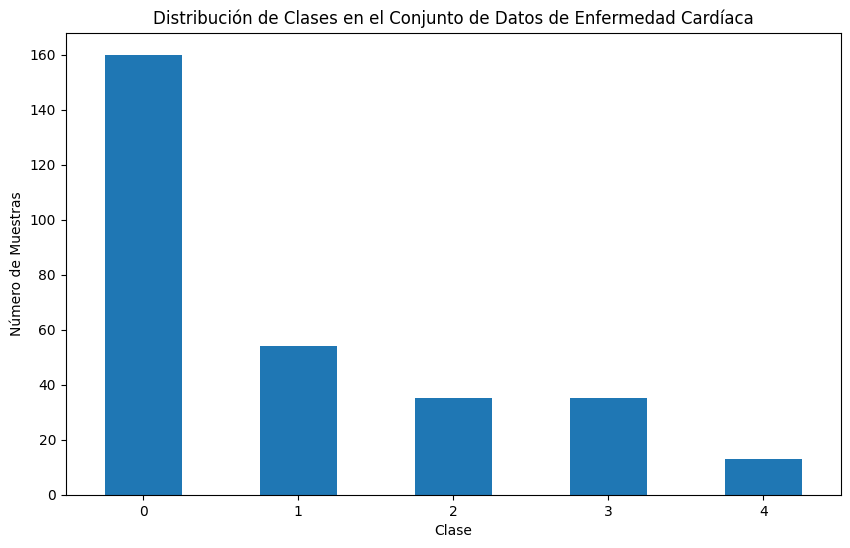

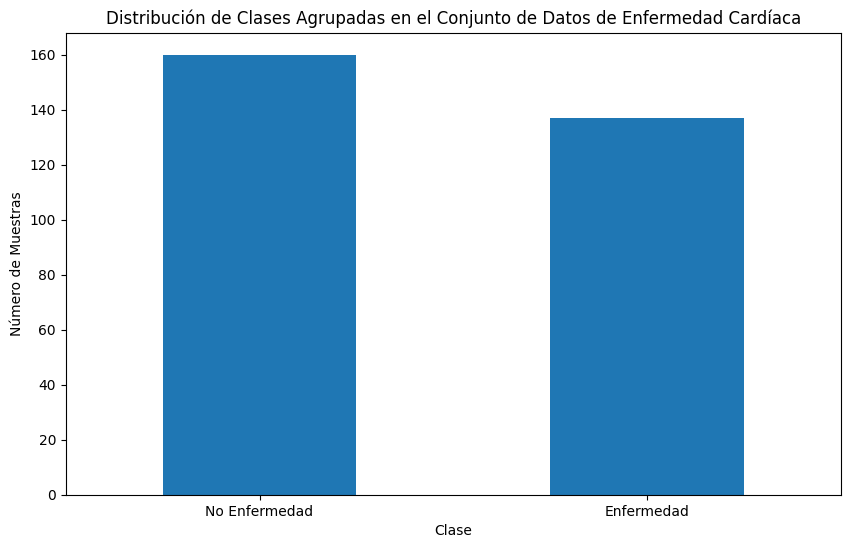

(target
 0    160
 1     54
 2     35
 3     35
 4     13
 Name: count, dtype: int64,
 target
 0    160
 1    137
 Name: count, dtype: int64)

In [3]:
import matplotlib.pyplot as plt

# We count the number of samples for each class in 'target'
class_counts = heart_disease_df_cleaned['target'].value_counts()

# We show the number of samples for each class
print(class_counts)

# Bar chart for the original classes
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.title('Distribución de Clases en el Conjunto de Datos de Enfermedad Cardíaca')
plt.xlabel('Clase')
plt.ylabel('Número de Muestras')
plt.xticks(rotation=0)
plt.show()

# We group the samples into two classes: '0' for absence of pathology and '1' for presence
heart_disease_binary = heart_disease_df_cleaned.copy()
heart_disease_binary['target'] = heart_disease_binary['target'].apply(lambda x: 0 if x == 0 else 1)

# We count the number of samples for the two grouped classes
binary_class_counts = heart_disease_binary['target'].value_counts()

# Bar chart for the grouped classes
plt.figure(figsize=(10, 6))
binary_class_counts.plot(kind='bar')
plt.title('Distribución de Clases Agrupadas en el Conjunto de Datos de Enfermedad Cardíaca')
plt.xlabel('Clase')
plt.ylabel('Número de Muestras')
plt.xticks([0, 1], ['No Enfermedad', 'Enfermedad'], rotation=0)
plt.show()

class_counts, binary_class_counts

The distribution of the samples for the original classes in the dataset shows the following counts:

Class 0 (absence of disease): 160 samples,
Class 1: 54 samples,
Class 2: 35 samples,
Class 3: 35 samples,
Class 4: 13 samples.


This distribution suggests that the dataset is imbalanced, especially when noting the larger number of samples for class 0 compared with the other classes.

Working with an imbalanced dataset can lead to several challenges:

Biased Models, where classification algorithms can become biased toward the most represented classes, improving performance on these at the cost of worse performance on the minority classes.
Conventional performance metrics may not adequately reflect the model's effectiveness across all classes, especially the less represented ones.
Detecting samples from minority classes can be more difficult, which is especially problematic in applications where correctly identifying these samples is crucial.


The distribution of samples in these two grouped classes is:
Class 0 (No Enfermedad, "No Disease"): 160 samples
Class 1 (Enfermedad, "Disease"): 137 samples

## 3. Normalization and train/test split

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# We prepare the data for normalization and splitting
X = heart_disease_binary.drop('target', axis=1)
y = heart_disease_binary['target']

# We normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# We split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# We check the dimensions of the training and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((207, 13), (90, 13), (207,), (90,))

## 4. Training an SVM and a decision tree

In [5]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# We train an SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
# We predict with the SVM model on the test set
svm_predictions = svm_model.predict(X_test)


# We train a decision tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
# We predict with the decision tree on the test set
tree_predictions = tree_model.predict(X_test)



### Confusion matrices

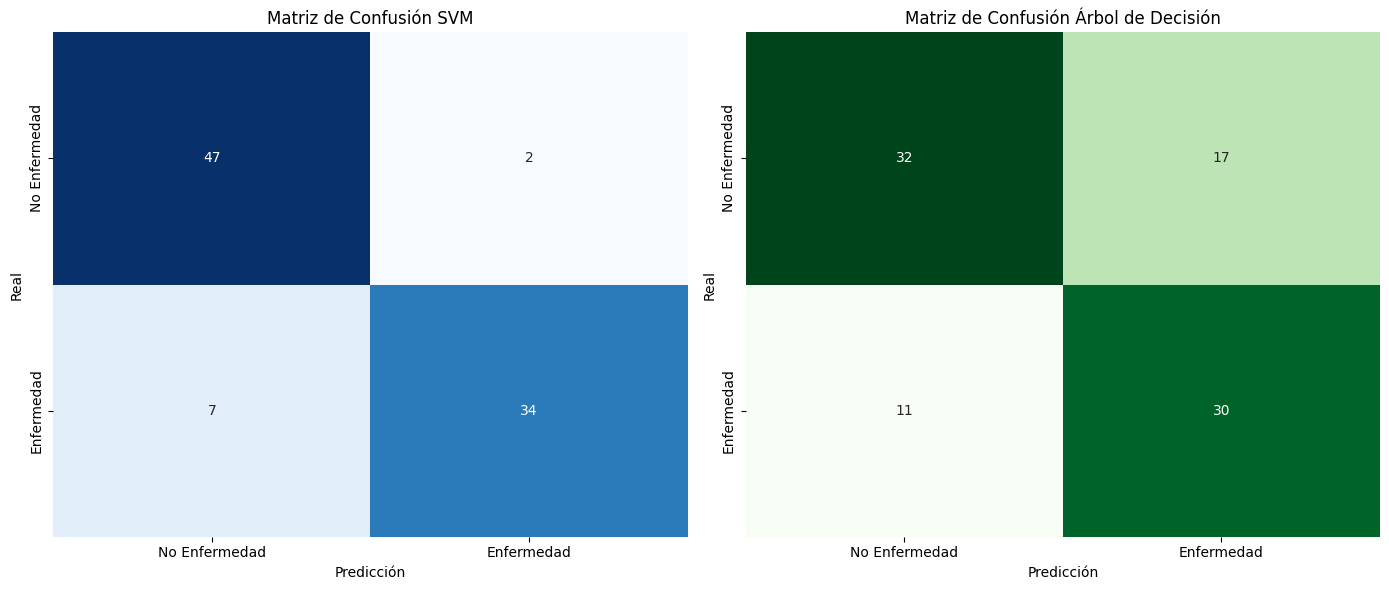

(array([[47,  2],
        [ 7, 34]]),
 array([[32, 17],
        [11, 30]]))

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# We compute the confusion matrices
svm_confusion_matrix = confusion_matrix(y_test, svm_predictions)
tree_confusion_matrix = confusion_matrix(y_test, tree_predictions)

# We plot the confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# SVM
sns.heatmap(svm_confusion_matrix, annot=True, fmt="d", ax=ax[0], cmap="Blues", cbar=False)
ax[0].set_title('Matriz de Confusión SVM')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Real')
ax[0].set_xticklabels(['No Enfermedad', 'Enfermedad'])
ax[0].set_yticklabels(['No Enfermedad', 'Enfermedad'])

# Decision Tree
sns.heatmap(tree_confusion_matrix, annot=True, fmt="d", ax=ax[1], cmap="Greens", cbar=False)
ax[1].set_title('Matriz de Confusión Árbol de Decisión')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Real')
ax[1].set_xticklabels(['No Enfermedad', 'Enfermedad'])
ax[1].set_yticklabels(['No Enfermedad', 'Enfermedad'])

plt.tight_layout()
plt.show()

svm_confusion_matrix, tree_confusion_matrix


SVM (Support Vector Machine):

True negatives (TN): 47
False positives (FP): 2
False negatives (FN): 7
True positives (TP): 34

Decision Tree:

True negatives (TN): 32
False positives (FP): 17
False negatives (FN): 11
True positives (TP): 30
Comments:

The SVM model has a high degree of accuracy in identifying both no-disease cases (TN) and disease cases (TP). The number of false negatives and false positives is relatively low, which indicates that the model is effective at correctly classifying the samples.

On the other hand, the Decision Tree has shown lower performance, especially in classifying no-disease cases, where the number of false positives is notably high. This indicates that the model has incorrectly classified a significant number of no-disease cases as if they had the disease.

### Precision, recall and F1-score

In [7]:
from sklearn.metrics import classification_report

# We compute precision, recall and f1-score for the SVM model
svm_classification_report = classification_report(y_test, svm_predictions, target_names=['No Enfermedad', 'Enfermedad'])

# We compute precision, recall and f1-score for the decision tree
tree_classification_report = classification_report(y_test, tree_predictions, target_names=['No Enfermedad', 'Enfermedad'])

print("Reporte de clasificación para SVM:\n", svm_classification_report)
print("Reporte de clasificación para Árbol de Decisión:\n", tree_classification_report)

Reporte de clasificación para SVM:
                precision    recall  f1-score   support

No Enfermedad       0.87      0.96      0.91        49
   Enfermedad       0.94      0.83      0.88        41

     accuracy                           0.90        90
    macro avg       0.91      0.89      0.90        90
 weighted avg       0.90      0.90      0.90        90

Reporte de clasificación para Árbol de Decisión:
                precision    recall  f1-score   support

No Enfermedad       0.74      0.65      0.70        49
   Enfermedad       0.64      0.73      0.68        41

     accuracy                           0.69        90
    macro avg       0.69      0.69      0.69        90
 weighted avg       0.70      0.69      0.69        90



SVM:

No Enfermedad:
Precision: 0.87
Recall: 0.96
F1-Score: 0.91
Enfermedad:
Precision: 0.94
Recall: 0.83
F1-Score: 0.88
Overall accuracy: 0.90


Decision Tree:

No Enfermedad:
Precision: 0.74
Recall: 0.65
F1-Score: 0.70
Enfermedad:
Precision: 0.64
Recall: 0.73
F1-Score: 0.68
Overall accuracy: 0.69

The SVM model has shown excellent performance in terms of precision, recall and F1-score for both classes. The high precision indicates that the model is very good at predicting positive cases (both disease and no-disease) correctly. The high recall for the "No Enfermedad" class suggests that the model is particularly effective at correctly identifying individuals without the disease. The combination of these factors results in high F1-scores, reflecting a good balance between precision and recall.

The Decision Tree shows lower precision and F1-score for both classes compared with the SVM. Although its recall for the "Enfermedad" class is relatively high, indicating a good ability to identify disease cases, the lower precision suggests that there is also a significant number of false positives (individuals classified as diseased when they are not).

## 5. Hyperparameter tuning with GridSearchCV

In [8]:
from sklearn.model_selection import GridSearchCV

# We define the parameter space for the SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf']
}

# We create the SVM model for the grid search
svm = SVC(random_state=42)

# We create the GridSearchCV object
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='accuracy')

# We run the grid search
grid_search.fit(X_train, y_train)

# We show the best combination of parameters
best_parameters = grid_search.best_params_
best_parameters


{'C': 0.1, 'kernel': 'rbf'}

### Retraining the SVM with the best parameters

In [9]:
# We train the SVM model with the best parameters found
optimized_svm_model = SVC(C=0.1, kernel='rbf', random_state=42)
optimized_svm_model.fit(X_train, y_train)

# We predict with the optimized SVM model on the test set
optimized_svm_predictions = optimized_svm_model.predict(X_test)

# We compute the accuracy of the optimized SVM model
optimized_svm_accuracy = accuracy_score(y_test, optimized_svm_predictions)

# We compute the confusion matrix
optimized_svm_confusion_matrix = confusion_matrix(y_test, optimized_svm_predictions)

# We compute precision, recall and f1-score
optimized_svm_classification_report = classification_report(y_test, optimized_svm_predictions, target_names=['No Enfermedad', 'Enfermedad'])

print(optimized_svm_accuracy, optimized_svm_confusion_matrix, optimized_svm_classification_report)


0.8888888888888888 [[47  2]
 [ 8 33]]                precision    recall  f1-score   support

No Enfermedad       0.85      0.96      0.90        49
   Enfermedad       0.94      0.80      0.87        41

     accuracy                           0.89        90
    macro avg       0.90      0.88      0.89        90
 weighted avg       0.89      0.89      0.89        90



Accuracy: 88.89%

Confusion Matrix:

True negatives (TN): 47
False positives (FP): 2
False negatives (FN): 8
True positives (TP): 33


No Enfermedad:
Precision: 0.85
Recall: 0.96
F1-Score: 0.90

Enfermedad:
Precision: 0.94
Recall: 0.80
F1-Score: 0.87
Overall accuracy: 0.89

Comparison with the Previous Results:

The overall accuracy has decreased slightly from 90% to 88.89% with the parameter optimization.
The confusion matrix shows a similar number of false positives (2) and a small increase in false negatives (from 7 to 8), which indicates a slight decrease in the model's ability to correctly identify disease cases.
The classification report shows a small decrease in precision for the "No Enfermedad" class and a decrease in recall for the "Enfermedad" class, although the precision for the latter class increased.

## 6. Discussion: robust evaluation in a clinical context

Especially in medical contexts where algorithmic bias can have significant consequences, I would consider the following additional analyses and strategies:

Evaluation of attribute importance, where identifying which attributes are most relevant for the prediction can help to understand which factors are being considered most by the model. This can be done using techniques such as feature importance analysis in decision trees or Random Forest. This evaluation can reveal whether the model is giving undue weight to features that may introduce biases.

Using stratified cross-validation instead of a simple train-test split can provide a more reliable evaluation of the model's performance. This ensures that each fold of the validation has the same proportion of classes as the original dataset, which is especially important in imbalanced datasets.

Analysis of ROC Curves and AUC for Binary Classifiers: they provide a more complete measure of the model's performance, especially for imbalanced data. These metrics can help to understand how the balance between sensitivity (recall) and specificity varies with different classification thresholds.

Considering metrics that compensate for class imbalance, such as balanced accuracy, can offer a more balanced view of the model's performance.

Model Robustness Tests: Performing stress tests on the models to evaluate how they respond to variations in the input data can help to identify vulnerabilities. This includes altering the class distribution or introducing noise into the data.